# 07 — Segmentazione temporale e analisi di sensitività

Questo notebook parte dalla mappa finale dei ruoli prodotta dal **06b** e:

1. usa soltanto le registrazioni valide;
2. carica, per ogni registrazione, il CSV di diarizzazione relativo al **canale selezionato**;
3. ricostruisce gli intervalli in cui parla il **paziente**;
4. genera finestre non sovrapposte da **10 s, 20 s e 30 s**;
5. calcola per ogni finestra la quota di parlato del paziente (`patient_speech_ratio`);
6. associa, quando disponibile, il `dn4_score`;
7. confronta le soglie **10%, 20%, 30%, 40%, 50%**.

> In questa fase non viene scelta definitivamente una soglia: la scelta verrà fatta
> dopo l'analisi di sensitività, come richiesto dal relatore.


In [2]:
from pathlib import Path
from math import gcd
import re
import warnings

import numpy as np
import pandas as pd
import soundfile as sf
from scipy.signal import resample_poly
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# Il notebook va eseguito dalla cartella principale ProgettoTesi.
PROJECT_DIR = Path.cwd()

AUDIO_DIR = PROJECT_DIR / "file_wav"
RESULTS_DIR = PROJECT_DIR / "risultati"
DIAR_DIR = RESULTS_DIR / "diarizzazione_batch" / "completo"
SELECTION_DIR = RESULTS_DIR / "selezione_canale"
SEGMENTATION_DIR = RESULTS_DIR / "segmentazione_finestre"
CLIPS_DIR = SEGMENTATION_DIR / "clip_audio"

ROLES_CSV = SELECTION_DIR / "mappa_ruoli_speaker_finale_semplificata.csv"
CHANNEL_CSV = SELECTION_DIR / "canale_scelto_per_registrazione.csv"

SEGMENTATION_DIR.mkdir(parents=True, exist_ok=True)
CLIPS_DIR.mkdir(parents=True, exist_ok=True)

WINDOW_SIZES = [10, 20, 30]
THRESHOLDS = [0.10, 0.20, 0.30, 0.40, 0.50]

# Manteniamo nei metadati tutte le finestre.
# Esportiamo l'audio di tutte le finestre, come nella versione precedente,
# così il confronto tra soglie non richiede di rigenerare i clip.
EXPORT_AUDIO = True
TARGET_SR = 16_000
KEEP_PARTIAL_WINDOWS = False

print("PROJECT_DIR:", PROJECT_DIR)
print("ROLES_CSV esiste:", ROLES_CSV.exists())
print("CHANNEL_CSV esiste:", CHANNEL_CSV.exists())
print("DIAR_DIR esiste:", DIAR_DIR.exists())
print("AUDIO_DIR esiste:", AUDIO_DIR.exists())
print("OUTPUT:", SEGMENTATION_DIR)


PROJECT_DIR: c:\Users\acer\Desktop\ProgettoTesi
ROLES_CSV esiste: True
CHANNEL_CSV esiste: True
DIAR_DIR esiste: True
AUDIO_DIR esiste: True
OUTPUT: c:\Users\acer\Desktop\ProgettoTesi\risultati\segmentazione_finestre


## 1. Caricamento della mappa finale dei ruoli

In [3]:
if not ROLES_CSV.exists():
    raise FileNotFoundError(
        f"File ruoli non trovato: {ROLES_CSV}\n"
        "Eseguire prima il notebook 06b."
    )

if not CHANNEL_CSV.exists():
    raise FileNotFoundError(CHANNEL_CSV)

if not DIAR_DIR.exists():
    raise FileNotFoundError(DIAR_DIR)

if not AUDIO_DIR.exists():
    raise FileNotFoundError(AUDIO_DIR)

roles = pd.read_csv(ROLES_CSV)
channels = pd.read_csv(CHANNEL_CSV)

for c in ["recording_id", "canale", "speaker", "ruolo_semplificato"]:
    if c in roles.columns:
        roles[c] = roles[c].fillna("").astype(str).str.strip()

for c in ["recording_id", "canale", "nome_file"]:
    if c in channels.columns:
        channels[c] = channels[c].fillna("").astype(str).str.strip()

# Teniamo nel file dei canali soltanto le 92 registrazioni effettivamente
# esportate dal 06b.
valid_recordings = set(roles["recording_id"].unique())

channels_valid = channels[
    channels["recording_id"].astype(str).isin(valid_recordings)
].copy()

print("Registrazioni valide nel file ruoli:", roles["recording_id"].nunique())
print("Speaker esportati:", len(roles))
print("Registrazioni trovate nel file canali:", channels_valid["recording_id"].nunique())

if channels_valid["recording_id"].nunique() != roles["recording_id"].nunique():
    missing = sorted(
        valid_recordings - set(channels_valid["recording_id"].astype(str))
    )
    print("ATTENZIONE - registrazioni mancanti nel file canali:")
    print(missing)

print("\nDistribuzione ruoli:")
display(
    roles["ruolo_semplificato"]
    .value_counts(dropna=False)
    .rename("conteggio")
    .to_frame()
)


Registrazioni valide nel file ruoli: 92
Speaker esportati: 195
Registrazioni trovate nel file canali: 92

Distribuzione ruoli:


,conteggio
ruolo_semplificato,
medico_altro,99
paziente,96


## 2. Caricamento della diarizzazione del canale selezionato

La diarizzazione del progetto è salvata in **un CSV separato per ogni registrazione/canale** nella cartella:

```text
risultati/diarizzazione_batch/completo
```

Per ciascuna delle 92 registrazioni valide viene caricato soltanto il CSV relativo al canale selezionato.


In [4]:
segmenti_selezionati = []
file_mancanti = []

for _, scelta in channels_valid.iterrows():
    recording_id = str(scelta["recording_id"])
    canale = str(scelta["canale"]).lower().strip()

    percorso_csv = DIAR_DIR / f"{recording_id}__{canale}.csv"

    if not percorso_csv.exists():
        file_mancanti.append(str(percorso_csv))
        continue

    df = pd.read_csv(percorso_csv)

    colonne_richieste = {
        "recording_id",
        "canale",
        "speaker",
        "inizio_secondi",
        "fine_secondi",
    }
    mancanti = colonne_richieste - set(df.columns)

    if mancanti:
        raise ValueError(
            f"Nel file {percorso_csv.name} mancano le colonne: {mancanti}"
        )

    df["recording_id"] = df["recording_id"].astype(str).str.strip()
    df["canale"] = df["canale"].astype(str).str.lower().str.strip()
    df["speaker"] = df["speaker"].astype(str).str.strip()

    df["inizio_secondi"] = pd.to_numeric(
        df["inizio_secondi"], errors="coerce"
    )
    df["fine_secondi"] = pd.to_numeric(
        df["fine_secondi"], errors="coerce"
    )

    df = df.dropna(
        subset=["inizio_secondi", "fine_secondi"]
    ).copy()

    df = df[
        df["fine_secondi"] > df["inizio_secondi"]
    ].copy()

    segmenti_selezionati.append(df)

if file_mancanti:
    print("CSV di diarizzazione mancanti:")
    for p in file_mancanti:
        print(" -", p)

if not segmenti_selezionati:
    raise RuntimeError(
        "Nessun CSV di diarizzazione è stato caricato."
    )

segmenti = pd.concat(
    segmenti_selezionati,
    ignore_index=True,
)

mappa_ruoli = roles[
    [
        "recording_id",
        "canale",
        "speaker",
        "ruolo_semplificato",
    ]
].drop_duplicates(
    ["recording_id", "canale", "speaker"]
)

segmenti = segmenti.merge(
    mappa_ruoli,
    on=["recording_id", "canale", "speaker"],
    how="left",
    validate="many_to_one",
)

print("Registrazioni caricate:", segmenti["recording_id"].nunique())
print("Segmenti diarizzati:", len(segmenti))
print(
    "Segmenti senza ruolo dopo il merge:",
    segmenti["ruolo_semplificato"].isna().sum(),
)

display(
    segmenti[
        [
            "recording_id",
            "canale",
            "speaker",
            "inizio_secondi",
            "fine_secondi",
            "ruolo_semplificato",
        ]
    ].head()
)


Registrazioni caricate: 92
Segmenti diarizzati: 10040
Segmenti senza ruolo dopo il merge: 0


,recording_id,canale,speaker,inizio_secondi,fine_secondi,ruolo_semplificato
0,ID1.StudioRuggi-006,destro,SPEAKER_00,0.368,1.027,medico_altro
1,ID1.StudioRuggi-006,destro,SPEAKER_01,1.567,3.338,paziente
2,ID1.StudioRuggi-006,destro,SPEAKER_00,4.064,5.380,medico_altro
3,ID1.StudioRuggi-006,destro,SPEAKER_01,5.903,7.878,paziente
4,ID1.StudioRuggi-006,destro,SPEAKER_00,6.713,7.439,medico_altro


## 3. Controllo dell'associazione tra diarizzazione e ruoli

In [5]:
if segmenti["ruolo_semplificato"].isna().any():
    problemi = segmenti[
        segmenti["ruolo_semplificato"].isna()
    ][
        ["recording_id", "canale", "speaker"]
    ].drop_duplicates()

    print("ATTENZIONE - segmenti senza ruolo associato:")
    display(problemi)
else:
    print("Tutti i segmenti diarizzati hanno un ruolo associato.")

patient_segments = segmenti[
    segmenti["ruolo_semplificato"] == "paziente"
].copy()

print(
    "Registrazioni con almeno un segmento del paziente:",
    patient_segments["recording_id"].nunique(),
    "/",
    segmenti["recording_id"].nunique(),
)


Tutti i segmenti diarizzati hanno un ruolo associato.
Registrazioni con almeno un segmento del paziente: 92 / 92


## 4. Funzioni di supporto

In [6]:
def unisci_intervalli(intervalli):
    intervalli = sorted(
        [
            (float(inizio), float(fine))
            for inizio, fine in intervalli
            if float(fine) > float(inizio)
        ],
        key=lambda x: x[0],
    )

    if not intervalli:
        return []

    uniti = [list(intervalli[0])]

    for inizio, fine in intervalli[1:]:
        if inizio <= uniti[-1][1]:
            uniti[-1][1] = max(uniti[-1][1], fine)
        else:
            uniti.append([inizio, fine])

    return [(inizio, fine) for inizio, fine in uniti]


def durata_intersezione(window_start, window_end, intervalli):
    totale = 0.0

    for inizio, fine in intervalli:
        totale += max(
            0.0,
            min(window_end, fine) - max(window_start, inizio),
        )

    return totale


def nome_sicuro(testo):
    return re.sub(
        r"[^A-Za-z0-9._-]+",
        "_",
        str(testo),
    ).strip("_")


def seleziona_canale_audio(audio, canale):
    if audio.ndim == 1:
        return audio

    canale = str(canale).lower()

    if audio.shape[1] == 1 or canale == "mono":
        return audio[:, 0]
    if canale == "sinistro":
        return audio[:, 0]
    if canale == "destro":
        return audio[:, 1]

    raise ValueError(f"Canale non riconosciuto: {canale}")


def ricampiona(audio, sample_rate, target_sr):
    if sample_rate == target_sr:
        return audio.astype(np.float32)

    divisore = gcd(int(sample_rate), int(target_sr))
    up = target_sr // divisore
    down = sample_rate // divisore

    return resample_poly(
        audio,
        up,
        down,
    ).astype(np.float32)


def estrai_patient_id(recording_id):
    m = re.search(
        r"ID\s*([0-9]+)",
        str(recording_id),
        flags=re.IGNORECASE,
    )
    return int(m.group(1)) if m else np.nan



def detect_column(columns, candidates):
    """Trova una colonna ignorando maiuscole/minuscole."""
    mapping = {
        str(c).strip().lower(): c
        for c in columns
    }

    for candidate in candidates:
        key = str(candidate).strip().lower()
        if key in mapping:
            return mapping[key]

    return None


## 5. Segmentazione in finestre da 10, 20 e 30 secondi

Vengono create **tutte le finestre complete e non sovrapposte**.  
Per ogni finestra viene calcolato `patient_speech_ratio`.

In questa fase **non viene applicata una soglia definitiva**: il valore viene conservato nei metadati e sarà confrontato successivamente alle soglie 10–50%.


In [7]:
righe_metadata = []

for indice_recording, (_, scelta) in enumerate(
    channels_valid.iterrows(),
    start=1,
):
    recording_id = str(scelta["recording_id"])
    nome_file = str(scelta["nome_file"])
    canale = str(scelta["canale"]).lower().strip()

    patient_id = (
        scelta["patient_id"]
        if "patient_id" in scelta.index
        else estrai_patient_id(recording_id)
    )

    print(
        f"[{indice_recording}/{len(channels_valid)}] "
        f"{recording_id} — {canale}"
    )

    percorso_audio = AUDIO_DIR / nome_file

    if not percorso_audio.exists():
        raise FileNotFoundError(
            f"Audio non trovato: {percorso_audio}"
        )

    audio, sample_rate = sf.read(
        percorso_audio,
        always_2d=True,
        dtype="float32",
    )

    traccia = seleziona_canale_audio(
        audio,
        canale,
    )
    durata_audio = len(traccia) / sample_rate

    df_reg = segmenti[
        segmenti["recording_id"].astype(str) == recording_id
    ].copy()

    df_paziente = df_reg[
        df_reg["ruolo_semplificato"] == "paziente"
    ]

    patient_speakers = sorted(
        df_paziente["speaker"]
        .astype(str)
        .unique()
        .tolist()
    )

    intervalli_paziente = unisci_intervalli(
        df_paziente[
            ["inizio_secondi", "fine_secondi"]
        ].itertuples(index=False, name=None)
    )

    for window_size in WINDOW_SIZES:
        if KEEP_PARTIAL_WINDOWS:
            numero_finestre = int(
                np.ceil(durata_audio / window_size)
            )
        else:
            numero_finestre = int(
                np.floor(durata_audio / window_size)
            )

        cartella_window = (
            CLIPS_DIR
            / f"{window_size}s"
            / nome_sicuro(recording_id)
        )

        if EXPORT_AUDIO:
            cartella_window.mkdir(
                parents=True,
                exist_ok=True,
            )

        for clip_index in range(numero_finestre):
            inizio = clip_index * window_size
            fine = min(
                inizio + window_size,
                durata_audio,
            )
            durata_clip = fine - inizio

            if (
                not KEEP_PARTIAL_WINDOWS
                and durata_clip < window_size
            ):
                continue

            patient_seconds = durata_intersezione(
                inizio,
                fine,
                intervalli_paziente,
            )

            patient_ratio = (
                patient_seconds / durata_clip
                if durata_clip > 0
                else 0.0
            )

            clip_id = (
                f"{nome_sicuro(recording_id)}"
                f"__{window_size}s"
                f"__{clip_index:04d}"
            )

            percorso_output = (
                cartella_window
                / f"{clip_id}.wav"
            )

            audio_exported = False

            if EXPORT_AUDIO:
                i0 = int(
                    round(inizio * sample_rate)
                )
                i1 = int(
                    round(fine * sample_rate)
                )

                clip_audio = traccia[i0:i1]
                clip_16k = ricampiona(
                    clip_audio,
                    sample_rate,
                    TARGET_SR,
                )

                sf.write(
                    percorso_output,
                    clip_16k,
                    TARGET_SR,
                )

                audio_exported = True

            righe_metadata.append({
                "patient_id": patient_id,
                "recording_id": recording_id,
                "nome_file": nome_file,
                "selected_channel": canale,
                "patient_speakers": "|".join(
                    patient_speakers
                ),
                "window_size_seconds": window_size,
                "clip_index": clip_index,
                "clip_id": clip_id,
                "start_seconds": round(inizio, 3),
                "end_seconds": round(fine, 3),
                "clip_duration_seconds": round(
                    durata_clip,
                    3,
                ),
                "patient_speech_seconds": round(
                    patient_seconds,
                    3,
                ),
                "patient_speech_ratio": round(
                    patient_ratio,
                    6,
                ),
                "patient_speech_percent": round(
                    patient_ratio * 100,
                    3,
                ),
                "audio_exported": audio_exported,
                "audio_path": (
                    str(percorso_output)
                    if audio_exported
                    else ""
                ),
            })

metadata = pd.DataFrame(righe_metadata)

if metadata.empty:
    raise RuntimeError(
        "Nessuna finestra generata."
    )

ALL_METADATA_CSV = (
    SEGMENTATION_DIR
    / "metadata_tutte_le_finestre.csv"
)

metadata.to_csv(
    ALL_METADATA_CSV,
    index=False,
)

print("\nFinestre totali:", len(metadata))
print(
    "Registrazioni segmentate:",
    metadata["recording_id"].nunique(),
)
print(
    "Pazienti distinti:",
    metadata["patient_id"].nunique(),
)
print("Metadata completo:", ALL_METADATA_CSV)

display(
    metadata.groupby(
        "window_size_seconds"
    )
    .size()
    .rename("numero_finestre")
    .to_frame()
)


[1/92] ID1.StudioRuggi-006 — destro
[2/92] ID10.StudioRuggi — sinistro
[3/92] ID101.StudioRuggi — destro
[4/92] ID103.StudioRuggi — mono
[5/92] ID104.StudioRuggi — sinistro
[6/92] ID11.StudioRuggi — destro
[7/92] ID112.StudioRuggi — sinistro
[8/92] ID114.StudioRuggi — sinistro
[9/92] ID116.StudioRuggi — sinistro
[10/92] ID117.StudioRuggi — sinistro
[11/92] ID118.StudioRuggi — sinistro
[12/92] ID12.StudioRuggi — destro
[13/92] ID121.StudioRuggi — sinistro
[14/92] ID122.StudioRuggi — sinistro
[15/92] ID126.StudioRuggi — sinistro
[16/92] ID129.StudioRuggi — sinistro
[17/92] ID13.StudioRuggi-001 — destro
[18/92] ID130.StudioRuggi — sinistro
[19/92] ID131.StudioRuggi — sinistro
[20/92] ID136.StudioRuggi — sinistro
[21/92] ID14.StudioRuggi — sinistro
[22/92] ID140.StudioRuggi — sinistro
[23/92] ID145.StudioRuggi — sinistro
[24/92] ID149.StudioRuggi — destro
[25/92] ID15.StudioRuggi — sinistro
[26/92] ID154.StudioRuggi — destro
[27/92] ID155.StudioRuggi — destro
[28/92] ID156.StudioRuggi — de

,numero_finestre
window_size_seconds,
10,3028
20,1495
30,976


## 6. Controlli di qualità prima dell'analisi delle soglie

In [9]:
quality = (
    metadata.groupby(
        ["recording_id", "window_size_seconds"]
    )
    .agg(
        n_finestre=("clip_index", "count"),
        n_finestre_con_paziente=(
            "patient_speech_ratio",
            lambda s: int((s > 0).sum()),
        ),
        media_patient_ratio=(
            "patient_speech_ratio",
            "mean",
        ),
        max_patient_ratio=(
            "patient_speech_ratio",
            "max",
        ),
    )
    .reset_index()
)

display(quality.head(20))

no_patient = (
    metadata.groupby(
        "recording_id"
    )["patient_speech_seconds"]
    .sum()
)

no_patient = no_patient[
    no_patient <= 0
]

if len(no_patient):
    print(
        "ATTENZIONE - registrazioni senza "
        "parlato paziente nelle finestre:"
    )
    display(
        no_patient.to_frame(
            "patient_speech_seconds"
        )
    )
else:
    print(
        "Tutte le registrazioni segmentate "
        "contengono parlato del paziente."
    )


,recording_id,window_size_seconds,n_finestre,n_finestre_con_paziente,media_patient_ratio,max_patient_ratio
0,ID1.StudioRuggi-006,10,32,32,0.637984,1.000000
1,ID1.StudioRuggi-006,20,16,16,0.637984,0.983150
2,ID1.StudioRuggi-006,30,10,10,0.630557,0.840233
3,ID10.StudioRuggi,10,20,19,0.297935,0.735200
4,ID10.StudioRuggi,20,10,10,0.297935,0.526500
5,ID10.StudioRuggi,30,6,6,0.320811,0.457267
6,ID101.StudioRuggi,10,28,28,0.207614,0.652400
7,ID101.StudioRuggi,20,14,14,0.207614,0.467600
8,ID101.StudioRuggi,30,9,9,0.211555,0.436867
9,ID103.StudioRuggi,10,52,52,0.554413,1.000000


Tutte le registrazioni segmentate contengono parlato del paziente.


## 7. Associazione opzionale dei punteggi DN4

In [10]:

def find_dn4_csv(base_dir):
    candidates = list(base_dir.rglob("*.csv"))

    # Priorità al nome già utilizzato nel progetto.
    preferred = [
        p for p in candidates
        if p.name.lower() == "record_id_dn4_score.csv"
    ]
    if preferred:
        return preferred[0]

    for p in candidates:
        try:
            sample = pd.read_csv(p, nrows=3)
        except Exception:
            continue

        low = {str(c).lower(): c for c in sample.columns}
        if "dn4_score" in low and (
            "record_id" in low or "patient_id" in low or "id" in low
        ):
            return p

    return None

DN4_CSV = find_dn4_csv(PROJECT_DIR)

if DN4_CSV is None:
    print(
        "CSV DN4 non trovato automaticamente. "
        "L'analisi di sensitività può comunque proseguire."
    )
    metadata_labeled = metadata.copy()
else:
    print("CSV DN4 trovato:")
    print(DN4_CSV)

    dn4 = pd.read_csv(DN4_CSV)

    dn4_id_col = detect_column(
        dn4.columns,
        ["record_id", "patient_id", "id"]
    )
    dn4_score_col = detect_column(
        dn4.columns,
        ["dn4_score"]
    )

    dn4_small = dn4[[dn4_id_col, dn4_score_col]].copy()
    dn4_small.columns = ["patient_id", "dn4_score"]

    dn4_small["patient_id"] = pd.to_numeric(
        dn4_small["patient_id"], errors="coerce"
    )
    dn4_small["dn4_score"] = pd.to_numeric(
        dn4_small["dn4_score"], errors="coerce"
    )

    dn4_small = dn4_small.dropna(subset=["patient_id"]).copy()
    dn4_small["patient_id"] = dn4_small["patient_id"].astype(int)
    dn4_small = dn4_small.drop_duplicates(subset=["patient_id"])

    metadata_labeled = metadata.merge(
        dn4_small,
        on="patient_id",
        how="left",
        validate="many_to_one",
    )

    metadata_labeled["patient_label"] = np.where(
        metadata_labeled["dn4_score"].isna(),
        np.nan,
        (metadata_labeled["dn4_score"] >= 4).astype(int),
    )

    print(
        "Finestre con DN4 disponibile:",
        metadata_labeled["dn4_score"].notna().sum(),
        "/",
        len(metadata_labeled),
    )

METADATA_LABELED = SEGMENTATION_DIR / "metadata_tutte_le_finestre_con_dn4.csv"
metadata_labeled.to_csv(METADATA_LABELED, index=False)

print("Salvato:")
print(METADATA_LABELED)


CSV DN4 trovato:
c:\Users\acer\Desktop\ProgettoTesi\record_id_dn4_score.csv
Finestre con DN4 disponibile: 5499 / 5499
Salvato:
c:\Users\acer\Desktop\ProgettoTesi\risultati\segmentazione_finestre\metadata_tutte_le_finestre_con_dn4.csv



## 8. Analisi di sensitività della soglia

Per ogni combinazione **durata della finestra × soglia** vengono calcolati:

- numero totale di finestre;
- numero e percentuale di finestre che sopravvivono;
- numero di pazienti che conservano almeno una finestra;
- numero di registrazioni che conservano almeno una finestra;
- mediana delle finestre sopravvissute per paziente.

Inoltre viene prodotto un file dettagliato **per paziente**, così da verificare che una soglia elevata non elimini completamente alcuni soggetti.


In [11]:

patient_rows = []
summary_rows = []

for window_size in WINDOW_SIZES:
    sub = metadata_labeled[
        metadata_labeled["window_size_seconds"] == window_size
    ].copy()

    total_windows = len(sub)
    total_patients = sub["patient_id"].nunique()
    total_recordings = sub["recording_id"].nunique()

    for threshold in THRESHOLDS:
        survives = sub["patient_speech_ratio"] >= threshold

        # Conteggio per paziente.
        per_patient = (
            sub.assign(sopravvive=survives)
            .groupby("patient_id")
            .agg(
                n_finestre_totali=("clip_index", "count"),
                n_finestre_sopravvissute=("sopravvive", "sum"),
                n_registrazioni=("recording_id", "nunique"),
                media_patient_ratio=("patient_speech_ratio", "mean"),
                max_patient_ratio=("patient_speech_ratio", "max"),
            )
            .reset_index()
        )

        per_patient["window_size_seconds"] = window_size
        per_patient["threshold"] = threshold
        per_patient["threshold_percent"] = int(round(threshold * 100))
        per_patient["percentuale_finestre_sopravvissute"] = (
            100
            * per_patient["n_finestre_sopravvissute"]
            / per_patient["n_finestre_totali"]
        )
        per_patient["paziente_mantenuto"] = (
            per_patient["n_finestre_sopravvissute"] > 0
        )

        # Aggiungiamo DN4, se disponibile.
        if "dn4_score" in sub.columns:
            patient_dn4 = (
                sub[["patient_id", "dn4_score", "patient_label"]]
                .drop_duplicates(subset=["patient_id"])
            )
            per_patient = per_patient.merge(
                patient_dn4,
                on="patient_id",
                how="left",
                validate="one_to_one",
            )

        patient_rows.append(per_patient)

        surviving_sub = sub[survives]
        per_patient_surv = (
            surviving_sub.groupby("patient_id")
            .size()
        )

        summary_rows.append({
            "window_size_seconds": window_size,
            "threshold": threshold,
            "threshold_percent": int(round(threshold * 100)),
            "finestre_totali": total_windows,
            "finestre_sopravvissute": int(survives.sum()),
            "percentuale_finestre_sopravvissute": (
                100 * survives.mean() if total_windows else np.nan
            ),
            "pazienti_totali": total_patients,
            "pazienti_mantenuti": int(
                surviving_sub["patient_id"].nunique()
            ),
            "pazienti_persi": int(
                total_patients
                - surviving_sub["patient_id"].nunique()
            ),
            "registrazioni_totali": total_recordings,
            "registrazioni_mantenute": int(
                surviving_sub["recording_id"].nunique()
            ),
            "mediana_clip_per_paziente": (
                float(per_patient_surv.median())
                if len(per_patient_surv)
                else 0.0
            ),
        })

sensitivity_patient = pd.concat(patient_rows, ignore_index=True)
sensitivity_summary = pd.DataFrame(summary_rows)

SENS_PATIENT = SEGMENTATION_DIR / "sensitivita_per_paziente.csv"
SENS_SUMMARY = SEGMENTATION_DIR / "sensitivita_riepilogo.csv"

sensitivity_patient.to_csv(SENS_PATIENT, index=False)
sensitivity_summary.to_csv(SENS_SUMMARY, index=False)

display(sensitivity_summary)

print("\nSalvati:")
print(SENS_PATIENT)
print(SENS_SUMMARY)


,window_size_seconds,threshold,threshold_percent,finestre_totali,finestre_sopravvissute,percentuale_finestre_sopravvissute,pazienti_totali,pazienti_mantenuti,pazienti_persi,registrazioni_totali,registrazioni_mantenute,mediana_clip_per_paziente
0,10,0.1,10,3028,2493,82.331572,90,90,0,92,92,25.0
1,10,0.2,20,3028,1961,64.762219,90,90,0,92,92,19.5
2,10,0.3,30,3028,1543,50.957728,90,90,0,92,91,14.0
3,10,0.4,40,3028,1176,38.837517,90,89,1,92,90,10.0
4,10,0.5,50,3028,881,29.095112,90,86,4,92,87,7.0
5,20,0.1,10,1495,1322,88.428094,90,90,0,92,92,14.0
6,20,0.2,20,1495,1096,73.311037,90,90,0,92,91,11.0
7,20,0.3,30,1495,833,55.719064,90,88,2,92,89,8.0
8,20,0.4,40,1495,592,39.598662,90,79,11,92,80,6.0
9,20,0.5,50,1495,406,27.157191,90,65,25,92,65,4.0



Salvati:
c:\Users\acer\Desktop\ProgettoTesi\risultati\segmentazione_finestre\sensitivita_per_paziente.csv
c:\Users\acer\Desktop\ProgettoTesi\risultati\segmentazione_finestre\sensitivita_riepilogo.csv


## 9. Grafici dell'analisi di sensitività

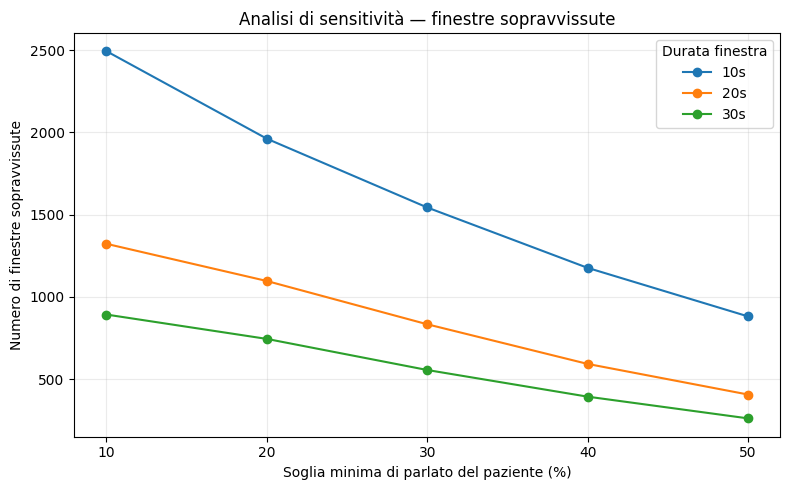

c:\Users\acer\Desktop\ProgettoTesi\risultati\segmentazione_finestre\sensitivita_finestre.png


In [12]:

fig = plt.figure(figsize=(8, 5))

for window_size in WINDOW_SIZES:
    tmp = sensitivity_summary[
        sensitivity_summary["window_size_seconds"] == window_size
    ]
    plt.plot(
        tmp["threshold_percent"],
        tmp["finestre_sopravvissute"],
        marker="o",
        label=f"{window_size}s",
    )

plt.xlabel("Soglia minima di parlato del paziente (%)")
plt.ylabel("Numero di finestre sopravvissute")
plt.title("Analisi di sensitività — finestre sopravvissute")
plt.xticks([10, 20, 30, 40, 50])
plt.grid(alpha=0.25)
plt.legend(title="Durata finestra")
plt.tight_layout()

PLOT_WINDOWS = SEGMENTATION_DIR / "sensitivita_finestre.png"
plt.savefig(PLOT_WINDOWS, dpi=160, bbox_inches="tight")
plt.savefig("img/Analisidisensitività.png", dpi=300, bbox_inches="tight")
plt.show()

print(PLOT_WINDOWS)


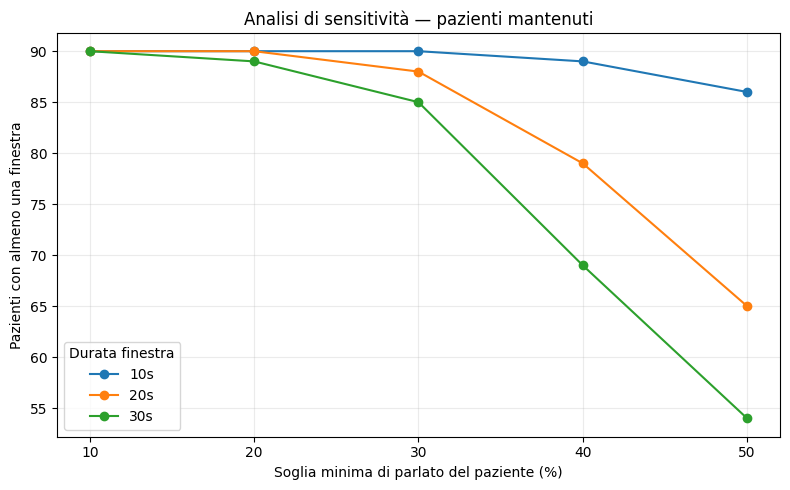

c:\Users\acer\Desktop\ProgettoTesi\risultati\segmentazione_finestre\sensitivita_pazienti.png


In [13]:

fig = plt.figure(figsize=(8, 5))

for window_size in WINDOW_SIZES:
    tmp = sensitivity_summary[
        sensitivity_summary["window_size_seconds"] == window_size
    ]
    plt.plot(
        tmp["threshold_percent"],
        tmp["pazienti_mantenuti"],
        marker="o",
        label=f"{window_size}s",
    )

plt.xlabel("Soglia minima di parlato del paziente (%)")
plt.ylabel("Pazienti con almeno una finestra")
plt.title("Analisi di sensitività — pazienti mantenuti")
plt.xticks([10, 20, 30, 40, 50])
plt.grid(alpha=0.25)
plt.legend(title="Durata finestra")
plt.tight_layout()

PLOT_PATIENTS = SEGMENTATION_DIR / "sensitivita_pazienti.png"
plt.savefig(PLOT_PATIENTS, dpi=160, bbox_inches="tight")
plt.savefig("img/Analisidisensitività-pazientimantenuti.png", dpi=300, bbox_inches="tight")
plt.show()

print(PLOT_PATIENTS)


## 10. Tabella compatta per la scelta della soglia

In [19]:

compact = sensitivity_summary[
    [
        "window_size_seconds",
        "threshold_percent",
        "finestre_sopravvissute",
        "percentuale_finestre_sopravvissute",
        "pazienti_mantenuti",
        "pazienti_persi",
        "mediana_clip_per_paziente",
    ]
].copy()

compact["percentuale_finestre_sopravvissute"] = (
    compact["percentuale_finestre_sopravvissute"].round(1)
)
compact["mediana_clip_per_paziente"] = (
    compact["mediana_clip_per_paziente"].round(1)
)

display(compact)


,window_size_seconds,threshold_percent,finestre_sopravvissute,percentuale_finestre_sopravvissute,pazienti_mantenuti,pazienti_persi,mediana_clip_per_paziente
0,10,10,2493,82.3,90,0,25.0
1,10,20,1961,64.8,90,0,19.5
2,10,30,1543,51.0,90,0,14.0
3,10,40,1176,38.8,89,1,10.0
4,10,50,881,29.1,86,4,7.0
5,20,10,1322,88.4,90,0,14.0
6,20,20,1096,73.3,90,0,11.0
7,20,30,833,55.7,88,2,8.0
8,20,40,592,39.6,79,11,6.0
9,20,50,406,27.2,65,25,4.0


In [20]:
# Controllo quali pazienti vengono persi alle varie soglie

persi = sensitivity_patient[
    sensitivity_patient["paziente_mantenuto"] == False
].copy()

if persi.empty:
    print("Nessun paziente viene perso alle soglie analizzate.")
else:
    # Associazione paziente -> registrazioni
    registrazioni_per_paziente = (
        metadata_labeled.groupby("patient_id")["recording_id"]
        .apply(lambda x: " | ".join(sorted(set(x.astype(str)))))
        .reset_index()
        .rename(columns={"recording_id": "registrazioni"})
    )

    persi = persi.merge(
        registrazioni_per_paziente,
        on="patient_id",
        how="left"
    )

    colonne = [
        "window_size_seconds",
        "threshold_percent",
        "patient_id",
        "registrazioni",
        "n_finestre_totali",
        "n_finestre_sopravvissute",
        "max_patient_ratio",
    ]

    # Aggiungiamo DN4 se presente
    if "dn4_score" in persi.columns:
        colonne += ["dn4_score", "patient_label"]

    persi = persi[colonne].sort_values(
        ["window_size_seconds", "threshold_percent", "patient_id"]
    )

    print("Pazienti persi alle diverse combinazioni durata/soglia:")
    display(persi)

Pazienti persi alle diverse combinazioni durata/soglia:


,window_size_seconds,threshold_percent,patient_id,registrazioni,n_finestre_totali,n_finestre_sopravvissute,max_patient_ratio,dn4_score,patient_label
0,10,40,36,ID36.StudioRuggi | ID36.StudioRuggi(2),32,0,0.306000,1.0,0.0
1,10,50,36,ID36.StudioRuggi | ID36.StudioRuggi(2),32,0,0.306000,1.0,0.0
2,10,50,63,ID63.StudioRuggi,25,0,0.469100,5.0,1.0
3,10,50,82,ID82.StudioRuggi,27,0,0.496100,2.0,0.0
4,10,50,93,ID93.StudioRuggi,27,0,0.422900,5.0,1.0
...,...,...,...,...,...,...,...,...,...
101,30,50,126,ID126.StudioRuggi,10,0,0.434900,6.0,1.0
102,30,50,136,ID136.StudioRuggi,8,0,0.420267,0.0,0.0
103,30,50,145,ID145.StudioRuggi,9,0,0.313300,0.0,0.0
104,30,50,154,ID154.StudioRuggi,9,0,0.372833,1.0,0.0


In [21]:
# Prima soglia alla quale ciascun paziente viene perso

prima_perdita = (
    persi.groupby(
        ["window_size_seconds", "patient_id"],
        as_index=False
    )
    .agg(
        prima_soglia_perdita=("threshold_percent", "min"),
        registrazioni=("registrazioni", "first"),
        max_patient_ratio=("max_patient_ratio", "first"),
    )
)

if "dn4_score" in persi.columns:
    info_dn4 = (
        persi[
            ["patient_id", "dn4_score", "patient_label"]
        ]
        .drop_duplicates("patient_id")
    )

    prima_perdita = prima_perdita.merge(
        info_dn4,
        on="patient_id",
        how="left"
    )

display(
    prima_perdita.sort_values(
        ["window_size_seconds", "prima_soglia_perdita", "patient_id"]
    )
)

,window_size_seconds,patient_id,prima_soglia_perdita,registrazioni,max_patient_ratio,dn4_score,patient_label
0,10,36,40,ID36.StudioRuggi | ID36.StudioRuggi(2),0.306000,1.0,0.0
1,10,63,50,ID63.StudioRuggi,0.469100,5.0,1.0
2,10,82,50,ID82.StudioRuggi,0.496100,2.0,0.0
3,10,93,50,ID93.StudioRuggi,0.422900,5.0,1.0
8,20,36,30,ID36.StudioRuggi | ID36.StudioRuggi(2),0.201700,1.0,0.0
...,...,...,...,...,...,...,...
55,30,91,50,ID91.StudioRuggi,0.451200,0.0,0.0
57,30,101,50,ID101.StudioRuggi,0.436867,4.0,1.0
58,30,116,50,ID116.StudioRuggi,0.403033,6.0,1.0
60,30,126,50,ID126.StudioRuggi,0.434900,6.0,1.0


In [ ]:
#paziente che viene perso con finestre da 30 s e soglia del 20%

display(
    prima_perdita[
        (prima_perdita["window_size_seconds"] == 30)
        & (prima_perdita["prima_soglia_perdita"] == 20)
    ]
)

,window_size_seconds,patient_id,prima_soglia_perdita,registrazioni,max_patient_ratio,dn4_score,patient_label
36,30,36,20,ID36.StudioRuggi | ID36.StudioRuggi(2),0.138933,1.0,0.0
